In [2]:
import os
import pickle
import glob
import sys
import getpass
import importlib
from tqdm import tqdm
from pathlib import Path

# user path:
usrname = getpass.getuser()
# add paths:
sys.path.append(f'/Users/{usrname}/Desktop/Projects')
sys.path.append(f'/Users/{usrname}/Desktop/Projects/bimanual_wrist')
sys.path.append(f'/Users/{usrname}/Desktop/Projects/Functional_Fusion')
sys.path.append(f'/Users/{usrname}/Desktop/Projects/PcmPy')

import rsatoolbox as rsa
from rsatoolbox.io import spm as spm_io
import surfAnalysisPy as surf
import SUITPy as suit
import nibabel as nb
import nitools as nt
import PcmPy as pcm
import Functional_Fusion.atlas_map as am
import Functional_Fusion.reliability as rel

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import seaborn as sns

import scipy.stats as stats
import scipy
import scipy.io as sio
import numpy as np
import pandas as pd

import utils
importlib.reload(utils)

font_path = '/Users/aghavamp/Library/Fonts/Calibri.ttf' 
fm.fontManager.addfont(font_path)
plt.rcParams.update({'font.size': 7, 'font.family':'Arial'})

# SET PATHS:
baseDir = os.path.join('/Users', getpass.getuser(), 'Desktop', 'Projects', 'bimanual_wrist', 'data', 'fMRI')
bidsDir = 'BIDS'
anatomicalDir = 'anatomicals'
freesurferDir = 'surfaceFreesurfer'
surfacewbDir = 'surfaceWB' 
behavDir = 'behavioural'
regDir = 'ROI'
atlasDir = '/Volumes/diedrichsen_data$/data/Atlas_templates/fs_LR_32'
analysisDir = os.path.join(os.path.dirname(os.path.dirname(baseDir)), 'analysis')



## Pearson r same movement

/var/folders/sc/kmc7_9gn2hqd_lrnhdt_2s580000gn/T/ipykernel_60131/2397025149.py:57: RuntimeWarning: Mean of empty slice.
  averaged_patterns[c, :] = measurements[condition_indices, :].mean(axis=0)
/Users/aghavamp/Desktop/Projects/bimanual_wrist/.conda/lib/python3.11/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/var/folders/sc/kmc7_9gn2hqd_lrnhdt_2s580000gn/T/ipykernel_60131/2397025149.py:57: RuntimeWarning: Mean of empty slice.
  averaged_patterns[c, :] = measurements[condition_indices, :].mean(axis=0)
/Users/aghavamp/Desktop/Projects/bimanual_wrist/.conda/lib/python3.11/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


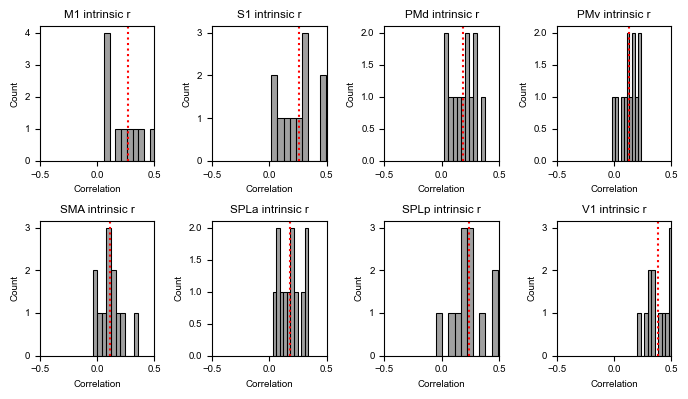

In [20]:
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']

df = {'region':[], 'r':[], 'fisher_Z':[]}

for region in regions:
    uni_file = os.path.join(analysisDir, f'pcm_dataset_12by12_{region}.npz')
    marginal_file = os.path.join(analysisDir, f'pcm_dataset_marginal_{region}.npz')

    # load pcm dataset:
    D_uni = np.load(uni_file, allow_pickle=True)
    D_marginal = np.load(marginal_file, allow_pickle=True)
    Y_uni = D_uni['Y']
    Y_marginal = D_marginal['Y']

    N_uni = len(Y_uni)
    r = []
    fisher_Z = []
    # loop on participants:
    for i in range(N_uni):
        # ================================ GET UNIMANUAL ================================
        measurements = Y_uni[i].measurements
        cond_vec = Y_uni[i].obs_descriptors['cond_vec']
        num_voxels = measurements.shape[1]
        ncond = 6

        # Create an array to store the averaged patterns for each condition
        averaged_patterns = np.zeros((ncond, num_voxels))

        # Loop through each condition and calculate the average pattern
        for c in range(ncond):
            # Find rows corresponding to the current condition
            condition_indices = cond_vec == c
            # Calculate the mean pattern for the current condition
            averaged_patterns[c, :] = measurements[condition_indices, :].mean(axis=0)

        # get the contra conditions: 
        y_contra_avg = averaged_patterns
        # remove mean across conditions:
        y_contra_avg = y_contra_avg - y_contra_avg.mean(axis=0)
        # flatten the averaged patterns:
        y_contra_vec = y_contra_avg.flatten()

        # ================================ GET BIMANUAL MARGINAL ================================
        measurements = Y_marginal[i].measurements
        cond_vec = Y_marginal[i].obs_descriptors['cond_vec']
        num_voxels = measurements.shape[1]
        ncond = 6

        # Create an array to store the averaged patterns for each condition
        averaged_patterns = np.zeros((ncond, num_voxels))

        # Loop through each condition and calculate the average pattern
        for c in range(ncond):
            # Find rows corresponding to the current condition
            condition_indices = cond_vec == c
            # Calculate the mean pattern for the current condition
            averaged_patterns[c, :] = measurements[condition_indices, :].mean(axis=0)
        
        # remove mean across conditions:
        y_marginal_avg = averaged_patterns - averaged_patterns.mean(axis=0)
        # flatten the averaged patterns:
        y_marginal_vec = y_marginal_avg.flatten()

        # concatenate the contra and ipsi patterns:
        r.append(np.corrcoef(y_contra_vec, y_marginal_vec)[0,1])
        fisher_Z.append(np.arctanh(r[-1]))

    r = np.array(r)
    fisher_Z = np.array(fisher_Z)
    df['region'].extend([region] * len(r))
    df['r'].extend(r)
    df['fisher_Z'].extend(fisher_Z)
df = pd.DataFrame(df)

# dist plot the correlations:
plt.rcParams.update({'font.size': 7})
fig, ax = plt.subplots(2,4,figsize=(7,4))
for region in regions:
    sns.histplot(df[df['region']==region]['r'], kde=False, color='gray', ax=ax.flatten()[regions.index(region)], bins=10)
    ax.flatten()[regions.index(region)].axvline(np.mean(df[df['region']==region]['r']), color='red', linestyle=':')
    ax.flatten()[regions.index(region)].set_xlabel('Correlation')
    ax.flatten()[regions.index(region)].set_ylabel('Count')
    ax.flatten()[regions.index(region)].set_title(f'{region} intrinsic r')
    ax.flatten()[regions.index(region)].set_xlim(-0.5,0.5)
plt.tight_layout()
plt.show()

